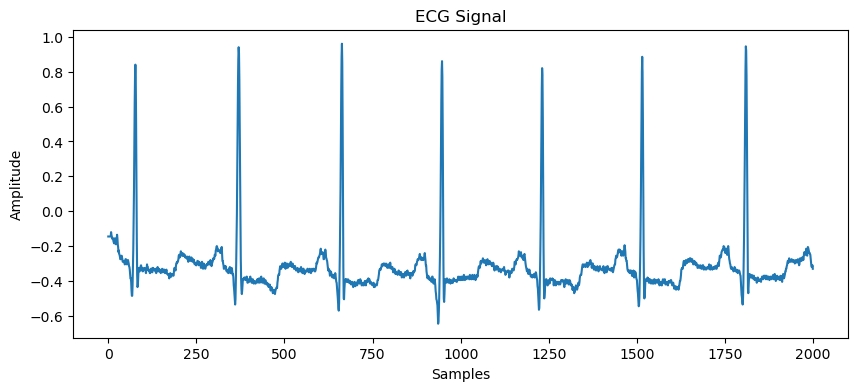

In [1]:
import wfdb
import matplotlib.pyplot as plt

record = wfdb.rdrecord('100')

signal = record.p_signal[:,0]

plt.figure(figsize=(10,4))
plt.plot(signal[:2000])
plt.title("ECG Signal")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.show()

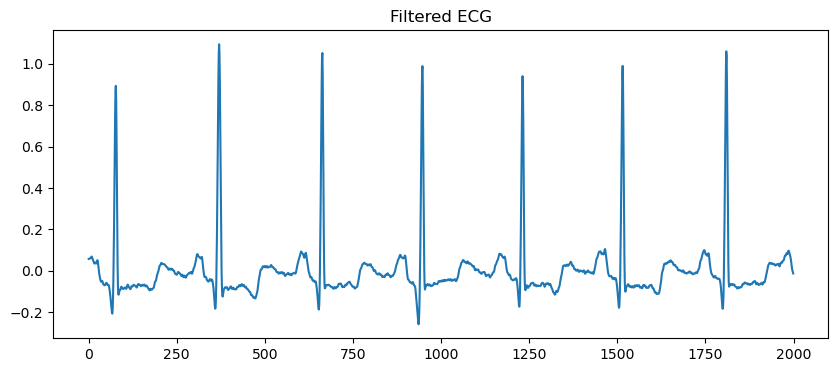

In [2]:
from scipy.signal import butter, filtfilt

def bandpass_filter(data, lowcut, highcut, fs):

    nyquist = 0.5 * fs
    low = lowcut / nyquist
    high = highcut / nyquist

    b, a = butter(1, [low, high], btype='band')

    filtered = filtfilt(b, a, data)

    return filtered

filtered_signal = bandpass_filter(signal,0.5,40,360)

plt.figure(figsize=(10,4))
plt.plot(filtered_signal[:2000])
plt.title("Filtered ECG")
plt.show()

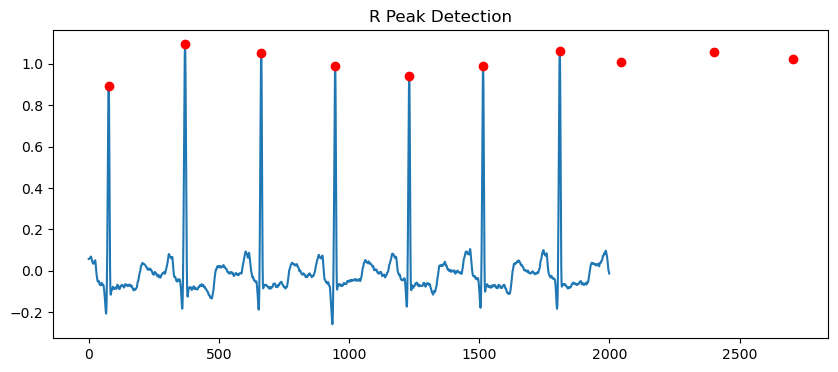

In [3]:
from scipy.signal import find_peaks

peaks,_ = find_peaks(filtered_signal,distance=200)

plt.figure(figsize=(10,4))
plt.plot(filtered_signal[:2000])
plt.plot(peaks[:10],filtered_signal[peaks[:10]],"ro")
plt.title("R Peak Detection")
plt.show()

In [4]:
import numpy as np

rr_intervals = np.diff(peaks)/360

heart_rate = 60/rr_intervals

print("Average Heart Rate:",np.mean(heart_rate))

Average Heart Rate: 75.7792352147102
